In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')

# Old Data

In [2]:
#old data training
df= pd.read_csv('final_data.csv')
#new data training
df= pd.read_csv('all_property_data.csv')

#excel data
df= pd.read_excel('Master.xlsx')
print(df)

            priceper    year dateoftransfer         borough  postcode  \
0        10208.33333  2022.0     2022-01-21  city of london  EC4A 1EP   
1        10422.07792  2015.0     2015-10-16  city of london  EC1Y 0ST   
2        15189.87342  2019.0     2019-08-16  city of london  EC2Y 5AG   
3        12780.61224  2015.0     2015-03-03  city of london  EC2Y 5AG   
4        14436.92308  2015.0     2015-01-29  city of london  EC2Y 5AG   
...              ...     ...            ...             ...       ...   
1048570          NaN     NaN            NaN             NaN       NaN   
1048571          NaN     NaN            NaN             NaN       NaN   
1048572          NaN     NaN            NaN             NaN       NaN   
1048573          NaN     NaN            NaN             NaN       NaN   
1048574          NaN     NaN            NaN             NaN       NaN   

                                  transactionid propertytype        food  \
0        {DE2D0CDF-F797-51EE-E053-6C04A8C00671}

In [3]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [8]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 19 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   priceper                 841575 non-null   float64
 1   year                     842191 non-null   float64
 2   dateoftransfer           842191 non-null   object 
 3   borough                  842191 non-null   object 
 4   postcode                 842191 non-null   object 
 5   transactionid            842191 non-null   object 
 6   propertytype             842191 non-null   object 
 7   food                     842191 non-null   float64
 8   education                842191 non-null   float64
 9   culture                  842191 non-null   float64
 10  central                  837338 non-null   float64
 11  ptal                     744077 non-null   float64
 12  crime_lagged_1yr         778472 non-null   float64
 13  cpih_lagged_1yr          842191 non-null  

Index(['priceper', 'year', 'dateoftransfer', 'borough', 'postcode',
       'transactionid', 'propertytype', 'food', 'education', 'culture',
       'central', 'ptal', 'crime_lagged_1yr', 'cpih_lagged_1yr',
       'mortgage_lagged_1yr', 'population_lagged_1yr', 'income_lagged_1yr',
       'unemployment_lagged_1yr', 'priceper_lagged_1yr'],
      dtype='object')

### All feature 

In [9]:
#print(df.iloc[:,1:].values)
# old
#x = df.iloc[:,0:6].values
#x = df.iloc[:,1:].values
x = pd.DataFrame(df.iloc[:,1:].values, columns=[ 'year', 'dateoftransfer', 'borough', 'postcode',
       'transactionid', 'propertytype', 'food', 'education', 'culture',
       'central', 'ptal', 'crime_lagged_1yr', 'cpih_lagged_1yr',
       'mortgage_lagged_1yr', 'population_lagged_1yr', 'income_lagged_1yr',
       'unemployment_lagged_1yr', 'priceper_lagged_1yr'])
#print(pd.DataFrame(df.iloc[:,1:].values))
print(type(x))
x.info()

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 18 columns):
 #   Column                   Non-Null Count    Dtype 
---  ------                   --------------    ----- 
 0   year                     842191 non-null   object
 1   dateoftransfer           842191 non-null   object
 2   borough                  842191 non-null   object
 3   postcode                 842191 non-null   object
 4   transactionid            842191 non-null   object
 5   propertytype             842191 non-null   object
 6   food                     842191 non-null   object
 7   education                842191 non-null   object
 8   culture                  842191 non-null   object
 9   central                  837338 non-null   object
 10  ptal                     744077 non-null   object
 11  crime_lagged_1yr         778472 non-null   object
 12  cpih_lagged_1yr          842191 non-null   object
 13  mortgage_lagged_1yr

### Actual Price

In [12]:
#print(df.iloc[:,0].values)

# old
# y = df.iloc[:,2].values
y = df.iloc[:,0].values
y = pd.DataFrame(df.iloc[:,0].values, columns=['priceper'])
print(pd.DataFrame(df.iloc[:,0].values))
print(type(y))
y.info()

                   0
0        10208.33333
1        10422.07792
2        15189.87342
3        12780.61224
4        14436.92308
...              ...
1048570          NaN
1048571          NaN
1048572          NaN
1048573          NaN
1048574          NaN

[1048575 rows x 1 columns]
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 1 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   priceper  841575 non-null  float64
dtypes: float64(1)
memory usage: 8.0 MB


In [13]:
print(x.select_dtypes(include=['object']).values)

[[2022.0 '2022-01-21' 'city of london' ... nan nan 13187.5]
 [2015.0 '2015-10-16' 'city of london' ... nan nan 10958.904109589]
 [2019.0 '2019-08-16' 'city of london' ... nan nan 11114.9570785739]
 ...
 [nan nan nan ... nan nan 6924.79743159013]
 [nan nan nan ... nan nan 6924.79743159013]
 [nan nan nan ... nan nan 7689.60492813141]]


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
x_categorical = x.select_dtypes(include=['object']).apply(label_encoder.fit_transform)
x_numerical = x.select_dtypes(exclude=['object']).values
x = pd.concat([pd.DataFrame(x_numerical), x_categorical], axis=1).values

regressor = RandomForestRegressor(n_estimators=10, random_state=40, oob_score=True)

regressor.fit(x, y)

AttributeError: 'numpy.ndarray' object has no attribute 'select_dtypes'

In [34]:
from sklearn.metrics import mean_squared_error, r2_score

oob_score = regressor.oob_score_
print(f'Out-of-Bag Score: {oob_score}')

predictions = regressor.predict(x)

mse = mean_squared_error(y, predictions)
print(f'Mean Squared Error: {mse}')

r2 = r2_score(y, predictions)
print(f'R-squared: {r2}')

Out-of-Bag Score: 0.9495075299229445
Mean Squared Error: 4443.10508972709
R-squared: 0.999641738550321


In [35]:
print(x[0])

[4.20634921e+03 2.02300000e+03 2.65000000e+05 6.30000000e+01
 3.00000000e+00 1.20000000e+01 7.60000000e+01 7.90000000e+01
 1.00000000e+00 2.95800000e+03 1.00000000e+00 1.00000000e+00
 3.77610000e+04 2.00000000e+00 5.54420000e+04 5.45813000e+05
 2.90000000e+01 8.80000000e+01 1.17000000e+02 0.00000000e+00]


In [ ]:
import numpy as np
   
#X_grid = np.arange(min(x[:, 2]), max(y[:, 2]), 0.01)  # Only the first feature
#X_grid = X_grid.reshape(-1, 1)
#X_grid = np.hstack((X_grid, np.zeros((X_grid.shape[0], 2))))  # Pad with zeros

#plt.scatter(x[0:10, 2], y[0:10, 2], color='blue', label="Actual Data")
#plt.scatter(x[0:10, 2], regressor.predict(x[0:10]), color='green', label="Random Forest Prediction")  
#plt.title("Random Forest Regression Results")
#plt.xlabel('Actual Price')
#plt.ylabel('Extimated Price')
#plt.legend()
#plt.show()
a = 0
for reg in regressor.predict(x[0:10]): 
    print('Actual => '+  str(x[a, 2]) +' Predicted => ' + str(reg) + ' Difference => ' + str(reg - x[a, 2]) + ' Error% => '+ str(((reg - x[a, 2])/x[a, 2])*100))
    a+=1

#print(regressor.predict(x[0].reshape(1, -1)))

a = 0
for reg in regressor.predict(x[0:10]): 
    print('Actual => '+  str(x[a, 2]) +' Predicted => ' + str(reg) + ' Difference => ' + str(reg - x[a, 2]) + ' Error% => '+ str(((reg - x[a, 2])/x[a, 2])*100))
    a+=1

Actual => 3326.0 Predicted => 3583.6 Difference => 257.5999999999999 Error% => 7.745039085989173
Actual => 3840.0 Predicted => 3859.2 Difference => 19.199999999999818 Error% => 0.4999999999999952
Actual => 4103.0 Predicted => 4082.2 Difference => -20.800000000000182 Error% => -0.5069461369729511
Actual => 4269.0 Predicted => 4223.9 Difference => -45.100000000000364 Error% => -1.056453501991107
Actual => 4158.0 Predicted => 4091.0 Difference => -67.0 Error% => -1.6113516113516115
Actual => 4250.0 Predicted => 4254.1 Difference => 4.100000000000364 Error% => 0.09647058823530268
Actual => 4646.0 Predicted => 4489.2 Difference => -156.80000000000018 Error% => -3.3749461902712055
Actual => 5055.0 Predicted => 4907.3 Difference => -147.69999999999982 Error% => -2.921859545004942
Actual => 4882.0 Predicted => 4804.2 Difference => -77.80000000000018 Error% => -1.5936091765669846
Actual => 4785.0 Predicted => 4726.8 Difference => -58.19999999999982 Error% => -1.2163009404388676


In [12]:
#print(df.iloc[].values)
#print(x[0:10])
print(x[1, 0])

2016.0


AttributeError: module 'matplotlib.pyplot' has no attribute 'set_xlim'

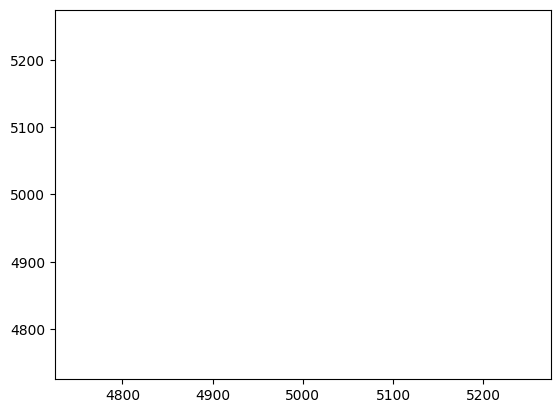

In [17]:
plt.plot(5000, 5000, color='green', label="Random Forest Prediction")  
plt.set_xlim(0,5000)
plt.set_ylim(0,5000)
plt.show()

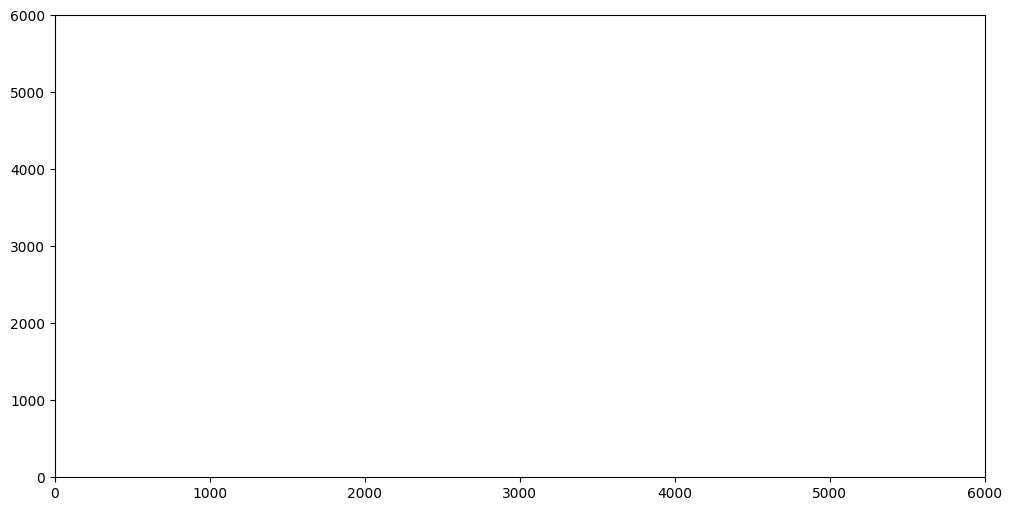

In [22]:
fig, ax = plt.subplots(sharex=True, figsize=(12, 6))
x=np.arange(0,24,1)

ax.plot(1000,5000, color='red', label='Bx',lw=1)
ax.plot (2000, 5000, color='blue', label = 'By',lw=1)
ax.set_xlim(0,6000)
ax.set_ylim(0,6000)

plt.show()

# New data

In [25]:
df= pd.read_csv('all_property_data.csv')
print(df)

            priceper  year dateoftransfer propertytype duration    price  \
0        4206.349206  2023     2023-11-28            F        L   265000   
1        4259.259259  2017     2017-06-28            F        L   230000   
2        3964.285714  2019     2019-12-13            S        F   333000   
3        4381.161008  2022     2022-12-09            F        L   200000   
4        4455.284553  2016     2016-11-11            S        F   548000   
...              ...   ...            ...          ...      ...      ...   
839047  11869.822917  2015     2015-03-13            F        L  1139503   
839048   9565.217391  2021     2021-04-30            F        L   440000   
839049  13431.372549  2015     2015-09-25            F        L  1370000   
839050   7954.545455  2017     2017-10-27            F        L   350000   
839051  12900.013333  2024     2024-07-12            T        F   967501   

        postcode    lad23cd                           transactionid  \
0       IG11 7GW